# SQLite and Visuals

Import libraries

In [36]:
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3
import plotly.express as px

Import data

In [37]:
hpi_df = pd.read_csv('data/hpi_clean.csv')
med_inc_df = pd.read_csv('data/median_income_clean_w_change.csv')

In [38]:
conn = sqlite3.connect("hpi_v_medinc.db")
cursor = conn.cursor()

In [39]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS hpi (
    hpi_type TEXT NOT NULL,
    hpi_flavor TEXT NOT NULL,
    frequency TEXT PRIMARY KEY,
    level TEXT NOT NULL,
    place_name REAL NOT NULL,
    yr TEXT NOT NULL,
    index_nsa TEST NOT NULL          
);        
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS medinc (
    place_name TEXT NOT NULL,
    yr TEXT NOT NULL,
    median_income TEXT NOT NULL,
    change TEXT NOT NULL
);
""")

hpi_df.to_sql('hpi', conn, if_exists='replace', index=False)
med_inc_df.to_sql('medinc', conn, if_exists='replace', index=False)

print(pd.read_sql_query("SELECT * FROM hpi LIMIT 5", conn))
print(pd.read_sql_query("SELECT * FROM medinc LIMIT 5", conn))

      hpi_type     hpi_flavor  frequency  level place_name place_id    yr  \
0  traditional  purchase-only  quarterly  State     Alaska       AK  1991   
1  traditional  purchase-only  quarterly  State     Alaska       AK  1992   
2  traditional  purchase-only  quarterly  State     Alaska       AK  1993   
3  traditional  purchase-only  quarterly  State     Alaska       AK  1994   
4  traditional  purchase-only  quarterly  State     Alaska       AK  1995   

   period  index_nsa  index_sa  
0       1     100.00    100.00  
1       1     103.06    103.01  
2       1     105.16    105.02  
3       1     111.51    111.26  
4       1     114.80    114.52  
  place_name    yr median_income  change standard_error
0    Alabama  1991        24,350  100.00          1,068
1    Alabama  1992        25,810  106.00          1,058
2    Alabama  1993        25,080  103.00          1,088
3    Alabama  1994        27,200  111.70          1,559
4    Alabama  1995        25,990  106.74          1,266


Query to show the largest gap between HPI and Median Income. I am also creating a new datafram to use in a visualization

In [50]:
main_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC

""")

Query to show the ten states with the lowest gap between HPI and Median Income.


In [51]:
lowest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap ASC
Limit 10  
""")



Query to show the 10 states with the largest gap between HPI and Median Income

In [52]:
largest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
Limit 10
""")

Query to show the most affordable states to live in in the years 1991 - 2024 showing a long term affordability not just current affordability. 

In [56]:
affordability_over_time_df = query("""
SELECT
    h.place_name,
    AVG(h.index_nsa / m.change) AS affordability_ratio
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
GROUP BY h.place_name
ORDER BY affordability_ratio ASC
LIMIT 10;
""")

Function to determine the gap between housing and income for the years 1991 - 2024. Instead of just the current year

In [59]:
def compare_states_with_gap(state1, state2):
    query_str = f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name IN ('{state1}', '{state2}')
    ORDER BY h.place_name, h.yr
    """
    
    return query(query_str)

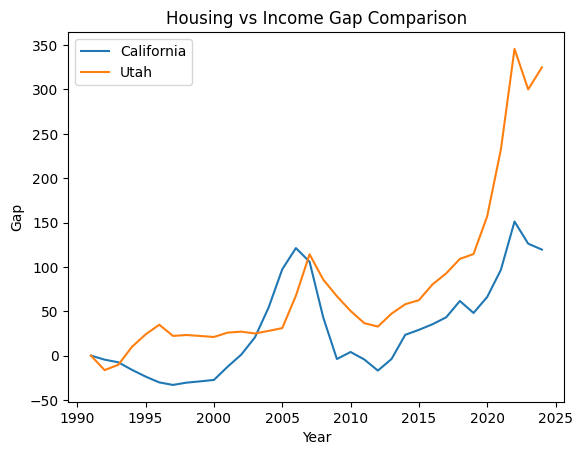

In [62]:
df = compare_states_with_gap('California', 'Utah')

for state in df['place_name'].unique():
    subset = df[df['place_name'] == state]
    plt.plot(subset['yr'], subset['gap'], label=state)

plt.legend()
plt.title('Housing vs Income Gap Comparison')
plt.xlabel('Year')
plt.ylabel('Gap')
plt.show()